In [4]:
import pandas as pd
import networkx as nx
from pathlib import Path
import json
from itertools import combinations
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

DATA_URL = "https://raw.githubusercontent.com/conwayyao/Recipe-Analysis/master/CuisineAnalyzer/cuisinedata/cuisine_data.csv"
GRAPHML_PATH = Path("ingredient_network.graphml")

# Data preprocessing

In [5]:
cuisine_df = pd.read_csv(DATA_URL).drop(columns=["Unnamed: 0"])
print(f"Dataset loaded with {len(cuisine_df)} recipes.")

def parse(x):
    if pd.isna(x) or x == "[]":
        return pd.NA
    if isinstance(x, list):
        return [i.strip().lower() for i in x]
    return list(i.strip().lower().strip("'\"") for i in x.strip("[]").split(", "))

cuisine_df["ingredient_set"] = cuisine_df["ingredients"].apply(parse)
cuisine_df["course_set"] = cuisine_df["course"].apply(parse)
cuisine_df["cuisine_set"] = cuisine_df["cuisine"].apply(parse)
cuisine_df = (
    cuisine_df
    .drop(columns=["ingredients", "course", "cuisine"])
    .rename(columns={
        "ingredient_set": "ingredients", 
        "course_set": "course", 
        "cuisine_set": "cuisine"
    })
)

cuisine_df = (
    cuisine_df
    .dropna(subset=["ingredients", "course", "cuisine", "totalTimeInSeconds"])
    .drop(columns=["rating"])
    .reset_index(drop=True)
)

def time_group(seconds, group_minutes=10, max_minutes=120):
    minutes = seconds / 60
    if minutes >= max_minutes:
        return "120+ min"
    start = int(minutes // group_minutes) * group_minutes
    end = start + group_minutes - 1
    return f"{start}-{end} min"

cuisine_df["time_group"] = cuisine_df["totalTimeInSeconds"].apply(time_group)
cuisine_df.drop(columns=["totalTimeInSeconds"], inplace=True)

cuisine_df

Dataset loaded with 8664 recipes.


,id,recipeName,ingredients,course,cuisine,time_group
0,Peanut-butter-fudge-297693,Peanut Butter Fudge,"[country crock® spread, light corn syrup, crea...",[desserts],[american],120+ min
1,Buckeyes-298471,Buckeyes,"[skippy® super chunk® peanut butter, country c...",[desserts],[american],110-119 min
2,Disappearing-buffalo-chicken-dip-297712,Disappearing Buffalo Chicken Dip,"[light mayonnaise, lemon juice, cayenne pepper...",[appetizers],[american],30-39 min
3,Classic-macaroni-salad-304692,Classic Macaroni Salad,"[elbow macaroni, hellmann' or best food real m...","[salads, side dishes]",[american],20-29 min
4,Classic-coleslaw-303481,Classic Coleslaw,"[hellmann' or best food real mayonnais, lemon ...","[salads, side dishes]","[american, southern & soul food]",10-19 min
...,...,...,...,...,...,...
7029,Thai-Coconut-Soup-MyRecipes-246201,Thai Coconut Soup,"[chicken broth, coconut milk, fish sauce, fres...",[soups],"[thai, asian]",40-49 min
7030,Thai-Coconut-Shrimp-Soup-901927,Thai Coconut Shrimp Soup,"[olive oil, large shrimp, carrots, garlic, gin...",[soups],[thai],20-29 min
7031,Spicy-Thai-Lobster-Soup-My-Recipes,Spicy Thai Lobster Soup,"[lobster, vegetable oil, asian, fish, lime rin...","[main dishes, soups]","[asian, thai]",50-59 min
7032,Thai-Green-Papaya-Salad-_Som-Tam_-1266284,Thai Green Papaya Salad (Som Tam),"[fresh lime juice, palm sugar, fish sauce, gar...",[main dishes],"[barbecue, thai]",20-29 min


In [6]:
cuisine_df.loc[cuisine_df["id"] == "Banana_caramel-Milk-Shake-My-Recipes", :]

,id,recipeName,ingredients,course,cuisine,time_group
253,Banana_caramel-Milk-Shake-My-Recipes,Banana-Caramel Milk Shake,"[caramel sauce, bananas, vanilla ice cream, milk]",[beverages],[american],20-29 min


# Data visualization

In [7]:
def clean_axis(ax, title: str, xlabel: str = "", ylabel: str = ""):
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    # remove box edges
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax

def plot_bar(series: pd.Series, title: str, xlabel: str, n: int = 20):
    top = series.head(n).sort_values()
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(top))))
    ax.barh(top.index, top.values)
    clean_axis(ax, title=title, xlabel=xlabel, ylabel="")
    for i, value in enumerate(top.values):
        ax.text(value, i, f" {value:,}", va="center", fontsize=9)
    plt.show()

def add_reference_lines(ax, values: pd.Series):
    mean_value = values.mean()
    median_value = values.median()
    ax.axvline(mean_value, linestyle="--", linewidth=1.5, label=f"Mean: {mean_value:.1f}")
    ax.axvline(median_value, linestyle=":", linewidth=1.8, label=f"Median: {median_value:.1f}")
    ax.legend(frameon=False)

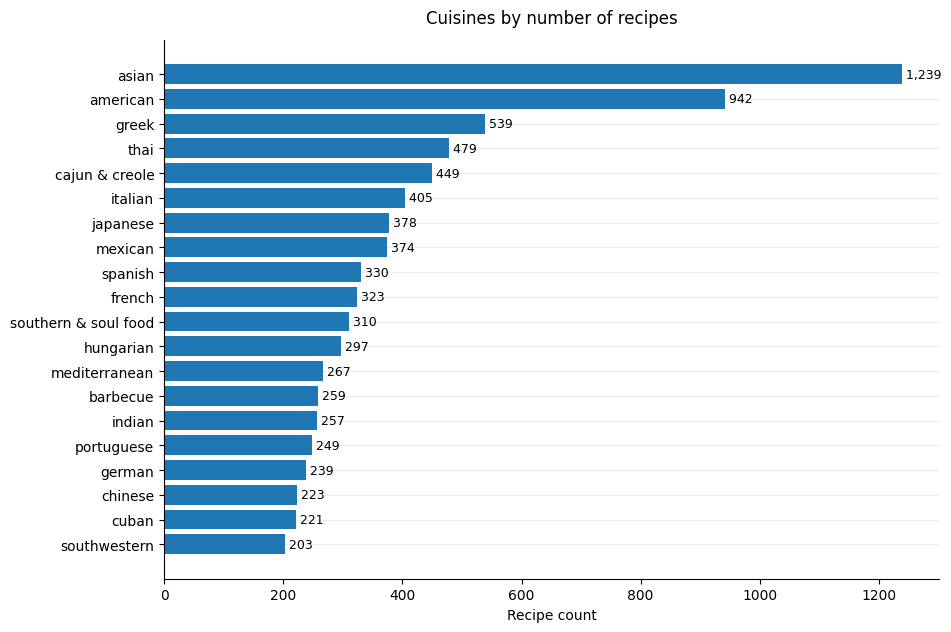

In [8]:
cuisine_counts = cuisine_df.explode("cuisine")["cuisine"].value_counts()
plot_bar(cuisine_counts, "Cuisines by number of recipes", "Recipe count")

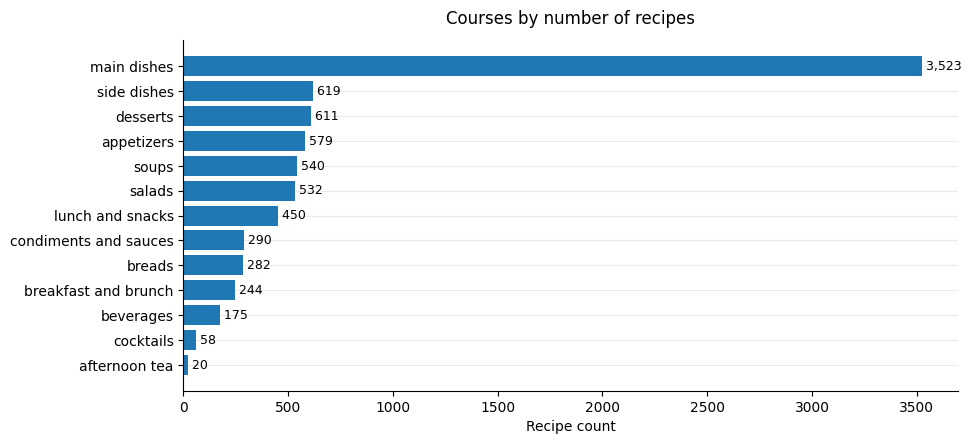

In [9]:
course_counts = cuisine_df.explode("course")["course"].value_counts()
plot_bar(course_counts, "Courses by number of recipes", "Recipe count")

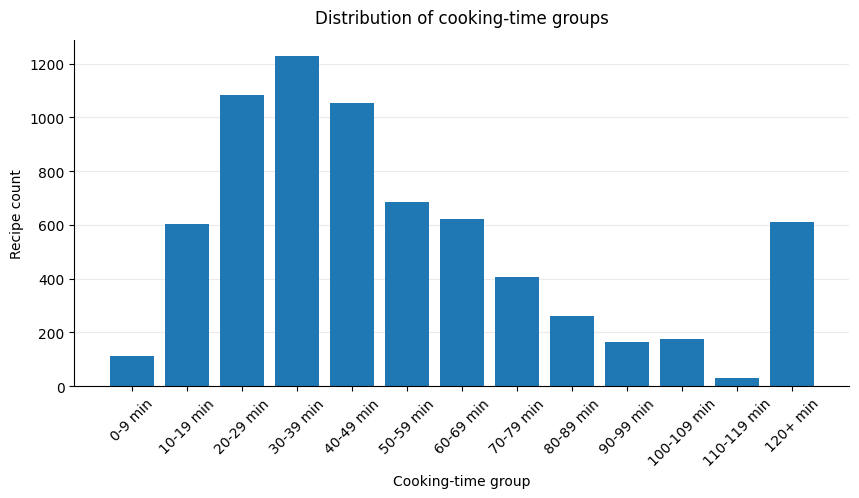

In [10]:
def time_group_order(group_minutes: int = 10, max_minutes: int = 120) -> list[str]:
    return [f"{start}-{start + group_minutes - 1} min" for start in range(0, max_minutes, group_minutes)] + [f"{max_minutes}+ min"]

time_counts = cuisine_df["time_group"].value_counts().reindex(time_group_order(), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(time_counts.index.astype(str), time_counts.values)
clean_axis(ax, "Distribution of cooking-time groups", "Cooking-time group", "Recipe count")
ax.tick_params(axis="x", rotation=45)
plt.show()

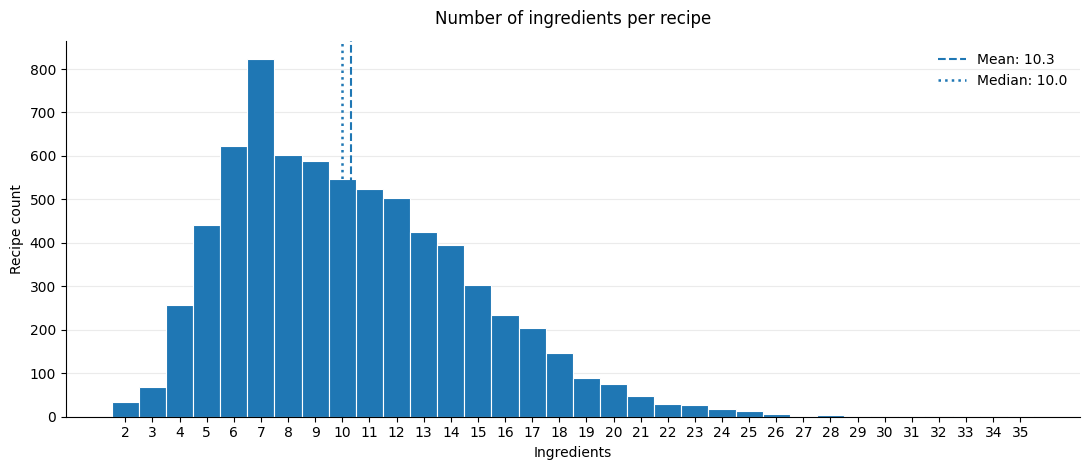

In [11]:
cuisine_df["n_ingredients"] = cuisine_df["ingredients"].map(len)
values = cuisine_df["n_ingredients"].dropna()
min_value = int(values.min())
max_value = int(values.max())

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.hist(
    values,
    bins=np.arange(min_value - 0.5, max_value + 1.5, 1),
    edgecolor="white",
    linewidth=0.8,
)
add_reference_lines(ax, values)
clean_axis(
    ax,
    "Number of ingredients per recipe",
    "Ingredients",
    "Recipe count",
)

ax.set_xticks(range(min_value, max_value + 1))
ax.tick_params(axis="x", labelrotation=0)

plt.tight_layout()
plt.show()

# Network

In [12]:
courses = dict()
cuisines = dict()
tgs = dict()
for _, row in cuisine_df.iterrows():
    for course in row["course"]:
        courses[course] = courses.get(course, 0) + 1
    for cuisine in row["cuisine"]:
        cuisines[cuisine] = cuisines.get(cuisine, 0) + 1
    tgs[row["time_group"]] = tgs.get(row["time_group"], 0) + 1

courses, cuisines, tgs

({'desserts': 611,
  'appetizers': 579,
  'salads': 532,
  'side dishes': 619,
  'condiments and sauces': 290,
  'main dishes': 3523,
  'lunch and snacks': 450,
  'breakfast and brunch': 244,
  'beverages': 175,
  'afternoon tea': 20,
  'breads': 282,
  'soups': 540,
  'cocktails': 58},
 {'american': 942,
  'southern & soul food': 310,
  'french': 323,
  'mexican': 374,
  'southwestern': 203,
  'asian': 1239,
  'kid-friendly': 89,
  'barbecue': 259,
  'cajun & creole': 449,
  'cuban': 221,
  'spanish': 330,
  'irish': 200,
  'italian': 405,
  'mediterranean': 267,
  'hawaiian': 173,
  'chinese': 223,
  'thai': 479,
  'japanese': 378,
  'indian': 257,
  'greek': 539,
  'english': 27,
  'german': 239,
  'hungarian': 297,
  'portuguese': 249,
  'moroccan': 162,
  'swedish': 194},
 {'120+ min': 610,
  '110-119 min': 29,
  '30-39 min': 1227,
  '20-29 min': 1082,
  '10-19 min': 604,
  '80-89 min': 260,
  '40-49 min': 1053,
  '100-109 min': 176,
  '60-69 min': 623,
  '50-59 min': 685,
  '0-9 

In [13]:
# node: ingredient = (number of recipes, {cuisine: number of recipes}, {course: ...}, {time group: ...})
# edge: ingredient1 <-> ingredient2 = (number of co-occurrence in recipes, {cuisine: number of co-occurrence}, {course: ...}, {time group: ...})

node_recipe_count = Counter()
node_cuisine_count = defaultdict(Counter)
node_course_count = defaultdict(Counter)
node_time_group_count = defaultdict(Counter)

edge_recipe_count = Counter()
edge_cuisine_count = defaultdict(Counter)
edge_course_count = defaultdict(Counter)
edge_time_group_count = defaultdict(Counter)

for idx, row in cuisine_df.iterrows():
    print(f"Processing recipe {idx+1}/{len(cuisine_df)}", end="\r")

    ingredients = row["ingredients"]
    cuisines = row["cuisine"]
    courses = row["course"]
    time_group = row["time_group"]

    if not isinstance(ingredients, list):
        continue

    ingredients = list(dict.fromkeys(ingredients))

    for ingredient in ingredients:
        node_recipe_count[ingredient] += 1

        if isinstance(cuisines, list):
            for cuisine in cuisines:
                node_cuisine_count[ingredient][cuisine] += 1

        if isinstance(courses, list):
            for course in courses:
                node_course_count[ingredient][course] += 1

        if pd.notna(time_group):
            node_time_group_count[ingredient][time_group] += 1

    for ingredient1, ingredient2 in combinations(ingredients, 2):
        edge = tuple(sorted((ingredient1, ingredient2)))

        edge_recipe_count[edge] += 1

        if isinstance(cuisines, list):
            for cuisine in cuisines:
                edge_cuisine_count[edge][cuisine] += 1

        if isinstance(courses, list):
            for course in courses:
                edge_course_count[edge][course] += 1

        if pd.notna(time_group):
            edge_time_group_count[edge][time_group] += 1

In [14]:
network = nx.Graph()

min_node_count = 0
min_edge_count = 0

valid_ingredients = {
    ingredient
    for ingredient, recipe_count in node_recipe_count.items()
    if recipe_count >= min_node_count
}

for ingredient in valid_ingredients:
    network.add_node(
        ingredient,
        recipe_count=node_recipe_count[ingredient],
        cuisines=dict(node_cuisine_count[ingredient]),
        courses=dict(node_course_count[ingredient]),
        time_groups=dict(node_time_group_count[ingredient])
    )

for (ingredient1, ingredient2), recipe_count in edge_recipe_count.items():
    if recipe_count < min_edge_count:
        continue
    if ingredient1 not in valid_ingredients or ingredient2 not in valid_ingredients:
        continue
    network.add_edge(
        ingredient1, ingredient2,
        recipe_count=recipe_count,
        cuisines=dict(edge_cuisine_count[(ingredient1, ingredient2)]),
        courses=dict(edge_course_count[(ingredient1, ingredient2)]),
        time_groups=dict(edge_time_group_count[(ingredient1, ingredient2)])
    )

network.number_of_nodes(), network.number_of_edges()

(3611, 130439)

In [24]:
network_graphml = network.copy()

for _, attrs in network_graphml.nodes(data=True):
    for key, value in list(attrs.items()):
        if isinstance(value, dict):
            attrs[key] = json.dumps(value)

for _, _, attrs in network_graphml.edges(data=True):
    for key, value in list(attrs.items()):
        if isinstance(value, dict):
            attrs[key] = json.dumps(value)

nx.write_graphml(network_graphml, GRAPHML_PATH)

# Network visualization

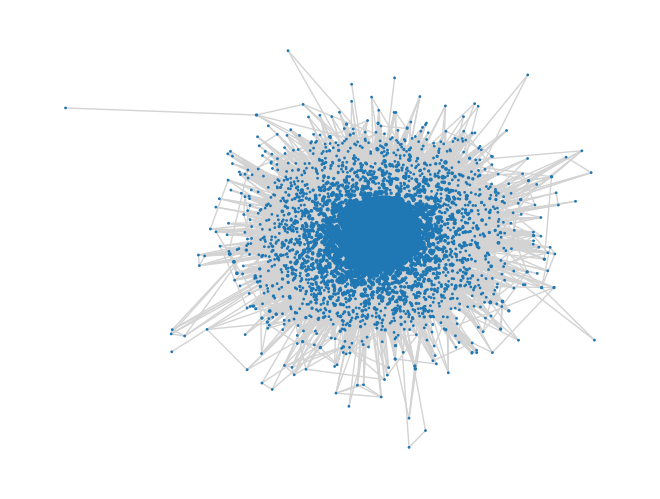

In [16]:
node_sizes = [network.nodes[node]['recipe_count'] for node in network.nodes()]
edge_widths = [network.edges[edge]['recipe_count']**(1/2) for edge in network.edges()]
nx.draw(network, node_size=node_sizes, edge_color="lightgray", width=edge_widths)

In [17]:
def safe_assortativity(G: nx.Graph) -> float:
    if G.number_of_edges() == 0 or G.number_of_nodes() < 3:
        return np.nan
    try:
        return nx.degree_assortativity_coefficient(G)
    except Exception:
        return np.nan


def network_summary(G: nx.Graph) -> pd.DataFrame:
    components = list(nx.connected_components(G))
    largest_cc_size = max((len(c) for c in components), default=0)
    degrees = dict(G.degree())
    strengths = dict(G.degree(weight="recipe_count"))

    summary = {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": nx.density(G),
        "connected_components": nx.number_connected_components(G),
        "largest_component_share": largest_cc_size / G.number_of_nodes() if G.number_of_nodes() else np.nan,
        "average_degree": np.mean(list(degrees.values())) if degrees else np.nan,
        "median_degree": np.median(list(degrees.values())) if degrees else np.nan,
        "average_strength": np.mean(list(strengths.values())) if strengths else np.nan,
        "average_clustering": nx.average_clustering(G) if G.number_of_nodes() else np.nan,
        "transitivity": nx.transitivity(G),
        "degree_assortativity": safe_assortativity(G),
    }
    return pd.DataFrame.from_dict(summary, orient="index", columns=["value"])

summary_table = network_summary(network)
summary_table

,value
nodes,3611.000000
edges,130439.000000
density,0.020013
connected_components,1.000000
largest_component_share,1.000000
average_degree,72.245361
median_degree,23.000000
average_strength,224.328995
average_clustering,0.755050
transitivity,0.219538
